In [37]:
import os 
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"]= "7"
import numpy as np

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

In [43]:
import torch
import torch.nn as nn
import numpy as np
import scipy.io
from matplotlib import pyplot as plt
import matplotlib.animation as animation

nu = 0.01

class NavierStokes():
    def __init__(self, X, Y, T, u, v):

        self.x = torch.tensor(X, dtype=torch.float32, requires_grad=True)
        self.y = torch.tensor(Y, dtype=torch.float32, requires_grad=True)
        self.t = torch.tensor(T, dtype=torch.float32, requires_grad=True)

        self.u = torch.tensor(u, dtype=torch.float32)
        self.v = torch.tensor(v, dtype=torch.float32)

        #null vector to test against f and g:
        self.null = torch.zeros((self.x.shape[0], 1))

        # initialize network:
        self.network()

        self.optimizer = torch.optim.LBFGS(self.net.parameters(), max_iter=200000, max_eval=50000,
                                           history_size=50, tolerance_grad=1e-05, tolerance_change=0.5 * np.finfo(float).eps,
                                           line_search_fn="strong_wolfe")

        self.mse = nn.MSELoss()

        #loss
        self.ls = 0

        #iteration number
        self.iter = 0
        self.print_interval = 100

    def network(self):

        self.net = nn.Sequential(
            nn.Linear(3, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 2))

    def function(self, x, y, t):

        res = self.net(torch.hstack((x, y, t)))
        psi, p = res[:, 0:1], res[:, 1:2]

        u = torch.autograd.grad(psi, y, grad_outputs=torch.ones_like(psi), create_graph=True)[0] #retain_graph=True,
        v = -1.*torch.autograd.grad(psi, x, grad_outputs=torch.ones_like(psi), create_graph=True)[0]

        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]

        v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
        v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
        v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]
        v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), create_graph=True)[0]

        p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
        p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]

        f = u_t + u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
        g = v_t + u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)

        return u, v, p, f, g

    def closure(self):
        # reset gradients to zero:
        self.optimizer.zero_grad()

        # u, v, p, g and f predictions:
        u_prediction, v_prediction, p_prediction, f_prediction, g_prediction = self.function(self.x, self.y, self.t)

        # calculate losses
        u_loss = self.mse(u_prediction, self.u)
        v_loss = self.mse(v_prediction, self.v)
        f_loss = self.mse(f_prediction, self.null)
        g_loss = self.mse(g_prediction, self.null)
        self.ls = u_loss + v_loss + f_loss +g_loss

        # derivative with respect to net's weights:
        self.ls.backward()

        self.iter += 1
        if not self.iter % 1:
            print('Iteration: {:}, Loss: {:0.6f}'.format(self.iter, self.ls))

        return self.ls

    def train(self):

        # training loop
        self.net.train()
        self.optimizer.step(self.closure)



In [44]:
N_train = 5000

data = scipy.io.loadmat('/home/hpcs_rnd/RAVINDRA_IISc/DATA/cylinder_wake.mat')

U_star = data['U_star']  # N x 2 x T
P_star = data['p_star']  # N x T
t_star = data['t']  # T x 1
X_star = data['X_star']  # N x 2

N = X_star.shape[0]
T = t_star.shape[0]

x_test = X_star[:, 0:1]
y_test = X_star[:, 1:2]
p_test = P_star[:, 0:1]
u_test = U_star[:, 0:1, 0]

t_test = np.ones((x_test.shape[0], x_test.shape[1]))

# Rearrange Data
XX = np.tile(X_star[:, 0:1], (1, T))  # N x T
YY = np.tile(X_star[:, 1:2], (1, T))  # N x T
TT = np.tile(t_star, (1, N)).T  # N x T

UU = U_star[:, 0, :]  # N x T
VV = U_star[:, 1, :]  # N x T
PP = P_star  # N x T

x = XX.flatten()[:, None]  # NT x 1
y = YY.flatten()[:, None]  # NT x 1
t = TT.flatten()[:, None]  # NT x 1

u = UU.flatten()[:, None]  # NT x 1
v = VV.flatten()[:, None]  # NT x 1
p = PP.flatten()[:, None]  # NT x 1

# Training Data
idx = np.random.choice(N * T, N_train, replace=False)
x_train = x[idx, :]
y_train = y[idx, :]
t_train = t[idx, :]
u_train = u[idx, :]
v_train = v[idx, :]


pinn = NavierStokes(x_train, y_train, t_train, u_train, v_train)

pinn.train()


# for i in range(1, 200001):  # Train for 1000 iterations
#     # Train for one batch
#     loss, accuracy = pinn.train()
    
#     if i % 100 == 0:  # Print every 100 iterations
#         print(f"Iteration {i}: Loss - {loss}, Accuracy - {accuracy}")

# torch.save(pinn.net.state_dict(), 'model.pt')


# pinn = NavierStokes(x_train, y_train, t_train, u_train, v_train)
# pinn.net.load_state_dict(torch.load('model.pt'))
# pinn.net.eval()

# x_test = torch.tensor(x_test, dtype=torch.float32, requires_grad=True)
# y_test = torch.tensor(y_test, dtype=torch.float32, requires_grad=True)
# t_test = torch.tensor(t_test, dtype=torch.float32, requires_grad=True)

# u_out, v_out, p_out, f_out, g_out = pinn.function(x_test, y_test, t_test)

# u_plot = p_out.data.cpu().numpy()
# u_plot = np.reshape(u_plot, (50, 100))

# fig, ax = plt.subplots()


# plt.contourf(u_plot, levels=30, cmap='jet')
# plt.colorbar()
# plt.show()



Iteration: 1, Loss: 0.893349
Iteration: 2, Loss: 0.893306
Iteration: 3, Loss: 0.893121
Iteration: 4, Loss: 0.891700
Iteration: 5, Loss: 0.879946
Iteration: 6, Loss: 0.652639
Iteration: 7, Loss: 0.651092
Iteration: 8, Loss: 0.649092
Iteration: 9, Loss: 170.844604
Iteration: 10, Loss: 5.047688
Iteration: 11, Loss: 0.881980
Iteration: 12, Loss: 0.648955
Iteration: 13, Loss: 0.620442
Iteration: 14, Loss: 0.521404
Iteration: 15, Loss: 0.552780
Iteration: 16, Loss: 0.502913
Iteration: 17, Loss: 0.469461
Iteration: 18, Loss: 0.438607
Iteration: 19, Loss: 0.407376
Iteration: 20, Loss: 0.383936
Iteration: 21, Loss: 0.361871
Iteration: 22, Loss: 0.331740
Iteration: 23, Loss: 0.280199
Iteration: 24, Loss: 0.270490
Iteration: 25, Loss: 0.258412
Iteration: 26, Loss: 0.275615
Iteration: 27, Loss: 0.247467
Iteration: 28, Loss: 0.235894
Iteration: 29, Loss: 0.227054
Iteration: 30, Loss: 0.221291
Iteration: 31, Loss: 0.218443
Iteration: 32, Loss: 0.217296
Iteration: 33, Loss: 0.214659
Iteration: 34, Lo

In [45]:
torch.save(pinn.net.state_dict(), 'model.pt')

In [93]:
p_test1 = P_star[:, 9:10]
u_test1 = U_star[:, 0:1, 10]

In [94]:
p_test1

array([[-0.11544903],
       [-0.11449573],
       [-0.11306064],
       ...,
       [-0.01055875],
       [-0.01011663],
       [-0.00946119]])

In [92]:
pinn.net.eval()

x_test = torch.tensor(x_test, dtype=torch.float32, requires_grad=True)
y_test = torch.tensor(y_test, dtype=torch.float32, requires_grad=True)
t_test = torch.tensor(t_test, dtype=torch.float32, requires_grad=True)

u_out, v_out, p_out, f_out, g_out = pinn.function(x_test, y_test, t_test)


In [84]:
t_star[10]

array([1.])

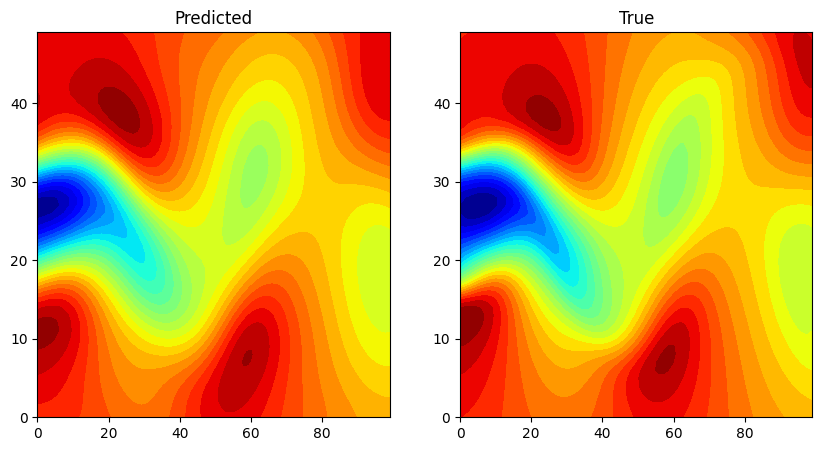

In [95]:


# Plotting Predicted Data
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plotting Predicted Data
u_plot_pred = u_out.data.cpu().numpy()
u_plot_pred = np.reshape(u_plot_pred, (50, 100))
axs[0].contourf(u_plot_pred, levels=30, cmap='jet')
axs[0].set_title('Predicted')

# Plotting True Data
u_plot_true = u_test1
u_plot_true = np.reshape(u_plot_true, (50, 100))
axs[1].contourf(u_plot_true, levels=30, cmap='jet')
axs[1].set_title('True')

# Adding Colorbar
# plt.colorbar(ax=axs.ravel().tolist(), orientation='vertical')

plt.show()


In [100]:
v_test1 = U_star[:,1,10].reshape(5000,1)
v_test1

array([[ 0.00902566],
       [ 0.01612149],
       [ 0.02299259],
       ...,
       [-0.05620308],
       [-0.07370743],
       [-0.08947238]])

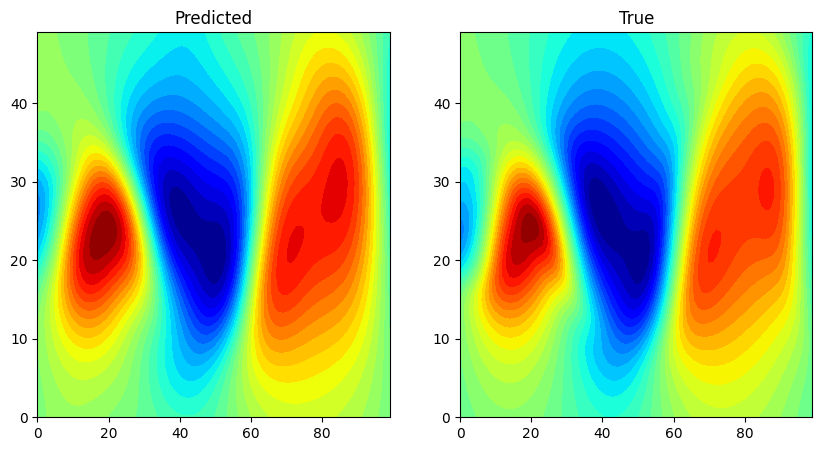

In [101]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plotting Predicted Data
v_plot_pred = v_out.data.cpu().numpy()
v_plot_pred = np.reshape(v_plot_pred, (50, 100))
axs[0].contourf(v_plot_pred, levels=30, cmap='jet')
axs[0].set_title('Predicted')

# Plotting True Data
v_plot_true = v_test1
v_plot_true = np.reshape(v_plot_true, (50, 100))
axs[1].contourf(v_plot_true, levels=30, cmap='jet')
axs[1].set_title('True')

# Adding Colorbar
# plt.colorbar(ax=axs.ravel().tolist(), orientation='vertical')

plt.show()

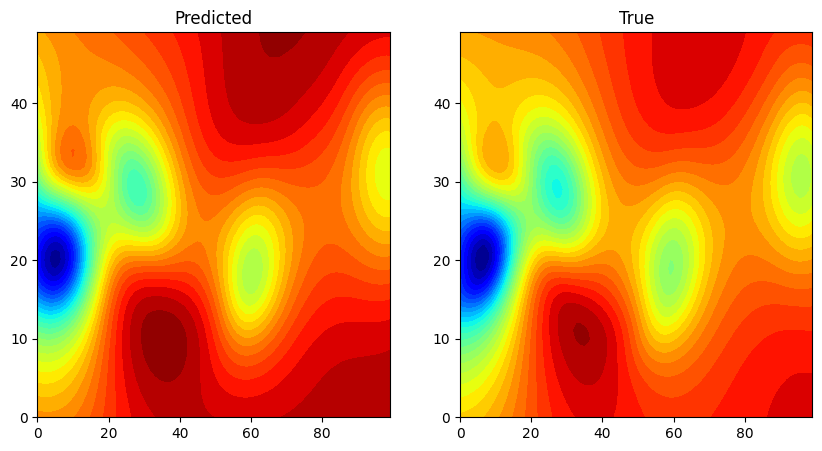

In [103]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plotting Predicted Data
p_plot_pred = p_out.data.cpu().numpy()
p_plot_pred = np.reshape(p_plot_pred, (50, 100))
axs[0].contourf(p_plot_pred, levels=30, cmap='jet')
axs[0].set_title('Predicted')

# Plotting True Data
p_plot_true = p_test1
p_plot_true = np.reshape(p_plot_true, (50, 100))
axs[1].contourf(p_plot_true, levels=30, cmap='jet')
axs[1].set_title('True')

# Adding Colorbar
#plt.colorbar(ax=axs.ravel().tolist(), orientation='vertical')

plt.show()

/tmp/ipykernel_37441/2885492561.py:3: UserWarning: The following kwargs were not used by contour: 'level'
  plt.contourf(p_plot_pred, level = 30, cmap= 'jet')


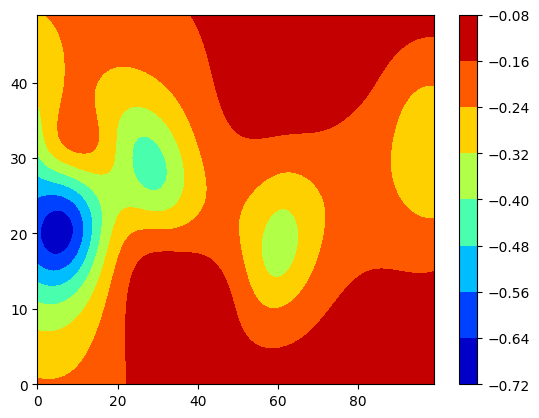

In [104]:
p_plot_pred = p_out.data.cpu().numpy()
p_plot_pred = np.reshape(p_plot_pred, (50, 100))
plt.contourf(p_plot_pred, level = 30, cmap= 'jet')
plt.colorbar()
plt.show()

/tmp/ipykernel_37441/3240078870.py:3: UserWarning: The following kwargs were not used by contour: 'level'
  plt.contourf(p_plot_true, level = 30, cmap= 'jet')


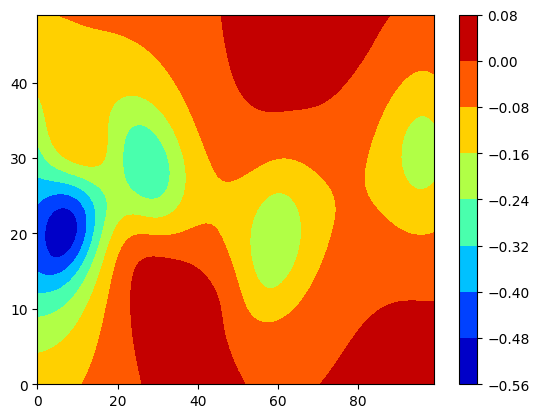

In [105]:
p_plot_true = p_test1
p_plot_true = np.reshape(p_plot_true, (50, 100))
plt.contourf(p_plot_true, level = 30, cmap= 'jet')
plt.colorbar()
plt.show()

In [28]:
def animate(i):
    ax.clear()
    # u_out, v_out, p_out, f_out, g_out = pinn.function(x_test, y_test, i*t_test)
    p_plot = p_out.data.cpu().numpy()
    p_plot = np.reshape(p_plot, (50, 100))
    cax = ax.contourf(p_plot, levels=20, cmap='jet')
    plt.xlabel(r'$x$')
    plt.xlabel(r'$y$')
    plt.title(r'$p(x,\; y, \; t)$')
ani = animation.FuncAnimation(fig,animate,20,interval=1,blit=False)
ani.save('pr_field_lbfgs.gif')
plt.close()

MovieWriter ffmpeg unavailable; using Pillow instead.


In [25]:
# def animate(i):
#     ax.clear()
#     u_out, v_out, p_out, f_out, g_out = pinn.function(x_test, y_test, i*t_test)

#     # Reshape and plot u_out
#     u_plot = u_out.data.cpu().numpy()
#     u_plot = np.reshape(u_plot, (50, 100))
#     u_contour = ax.contourf(u_plot, levels=20, cmap='jet', label='u')  # Add label for clarity

#     # Reshape and plot v_out (assuming v_out has the same shape as u_out)
#     v_plot = v_out.data.cpu().numpy()
#     v_plot = np.reshape(v_plot, (50, 100))
#     v_quiver = ax.quiver(x_test, y_test, v_plot[::2, ::2], u_plot[::2, ::2], scale=5, label='v')  # Subsample and scale for visualization

#     # Add colorbar and labels
#     plt.colorbar(u_contour, label='u')  # Add colorbar label
#     plt.xlabel(r'$x$')
#     plt.ylabel(r'$y$')
#     plt.title(r'$p(x,\; y, \; t)$ at t={}'.format(i*t_test))
#     plt.legend()  # Add legend for clarity

# ani = animation.FuncAnimation(fig, animate, 20, interval=1, blit=False)
# ani.save('p_field_lbfgs.gif')
# plt.close()


/tmp/ipykernel_37441/3679890308.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(x_test, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_37441/3679890308.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_37441/3679890308.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_test = torch.tensor(t_test, dtype=torch.float32, requires_grad=True)


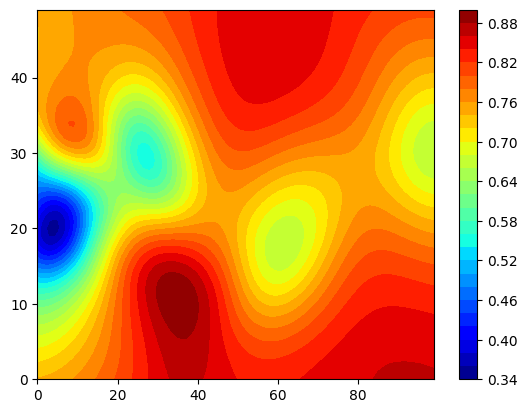

MovieWriter ffmpeg unavailable; using Pillow instead.


In [34]:
x_test = torch.tensor(x_test, dtype=torch.float32, requires_grad=True)
y_test = torch.tensor(y_test, dtype=torch.float32, requires_grad=True)
t_test = torch.tensor(t_test, dtype=torch.float32, requires_grad=True)

u_out, v_out, p_out, f_out, g_out = pinn.function(x_test, y_test, t_test)

p_plot = p_out.data.cpu().numpy()
p_plot = np.reshape(p_plot, (50, 100))

fig, ax = plt.subplots()

plt.contourf(p_plot, levels=30, cmap='jet')
plt.colorbar()
plt.show()

def animate(i):
    ax.clear()
    u_out, v_out, p_out, f_out, g_out = pinn.function(x_test, y_test, i*t_test)
    p_plot = p_out.data.cpu().numpy()
    p_plot = np.reshape(p_plot, (50, 100))
    cax = ax.contourf(p_plot, levels=20, cmap='jet')
    plt.xlabel(r'$x$')
    plt.xlabel(r'$y$')
    plt.title(r'$p(x,\; y, \; t)$')

# Call animate method
ani = animation.FuncAnimation(fig, animate, 20, interval=1, blit=False)
ani.save('p_field_lbfgs.gif')
plt.close()


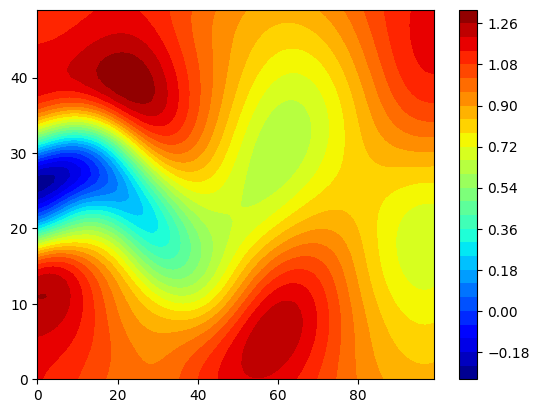

MovieWriter ffmpeg unavailable; using Pillow instead.


In [35]:
u_plot = u_out.data.cpu().numpy()
u_plot = np.reshape(u_plot, (50, 100))

fig, ax = plt.subplots()

plt.contourf(u_plot, levels=30, cmap='jet')
plt.colorbar()
plt.show()

def animate(i):
    ax.clear()
    u_out, v_out, p_out, f_out, g_out = pinn.function(x_test, y_test, i*t_test)
    u_plot = u_out.data.cpu().numpy()
    u_plot = np.reshape(u_plot, (50, 100))
    cax = ax.contourf(u_plot, levels=20, cmap='jet')
    plt.xlabel(r'$x$')
    plt.xlabel(r'$y$')
    plt.title(r'$p(x,\; y, \; t)$')

# Call animate method
ani = animation.FuncAnimation(fig, animate, 20, interval=1, blit=False)
ani.save('u_field_lbfgs.gif')
plt.close()

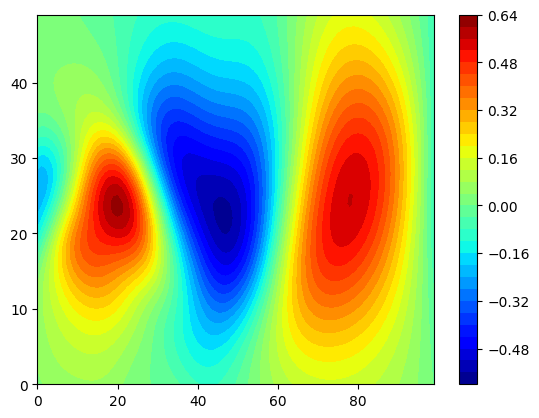

MovieWriter ffmpeg unavailable; using Pillow instead.


In [36]:
v_plot = v_out.data.cpu().numpy()
v_plot = np.reshape(v_plot, (50, 100))

fig, ax = plt.subplots()

plt.contourf(v_plot, levels=30, cmap='jet')
plt.colorbar()
plt.show()

def animate(i):
    ax.clear()
    u_out, v_out, p_out, f_out, g_out = pinn.function(x_test, y_test, i*t_test)
    v_plot = v_out.data.cpu().numpy()
    v_plot = np.reshape(v_plot, (50, 100))
    cax = ax.contourf(v_plot, levels=20, cmap='jet')
    plt.xlabel(r'$x$')
    plt.xlabel(r'$y$')
    plt.title(r'$p(x,\; y, \; t)$')

# Call animate method
ani = animation.FuncAnimation(fig, animate, 20, interval=1, blit=False)
ani.save('v_field_lbfgs.gif')
plt.close()